# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset.

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [3]:
# to be able to see multiple outputs from single cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# Inspect the shapes of the datasets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

# Convert labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("y_train shape after one-hot:", y_train.shape)
print("y_test shape after one-hot:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000, 10)
X_test shape: (10000, 28, 28)
y_test shape: (10000, 10)
y_train shape after one-hot: (60000, 10, 10)
y_test shape after one-hot: (10000, 10, 10)


<Figure size 1000x1000 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'T-shirt/top')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

<Axes: >

...

Text(0.5, 1.0, 'T-shirt/top')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

<Axes: >

Text(0.5, 1.0, 'T-shirt/top')

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

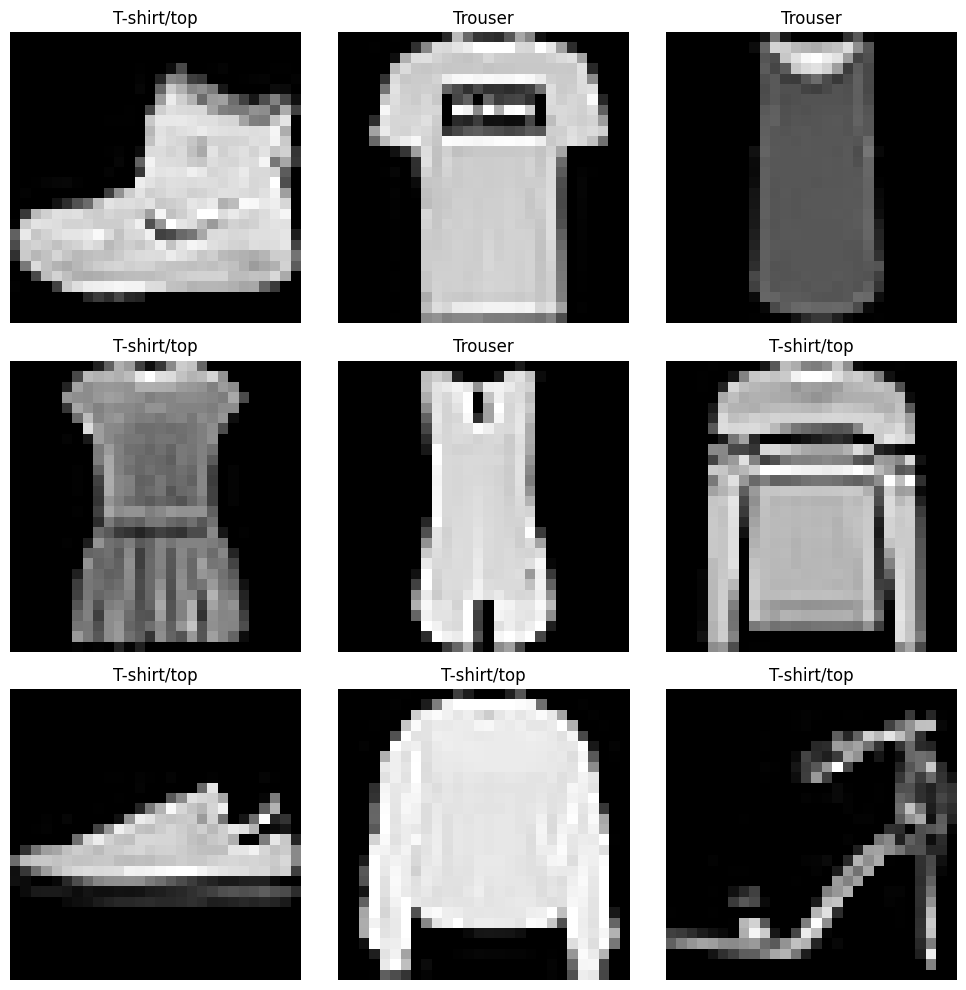

In [5]:
import matplotlib.pyplot as plt
# Verify the data looks as expected

import numpy as np

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis('off')

plt.tight_layout()
plt.show()


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [8]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.losses import SparseCategoricalCrossentropy

# ---- Fix label shape if one-hot was applied twice ----
# If y is (N, 10, 10) -> reduce to (N,)
if len(y_train.shape) == 3:
    y_train = np.argmax(y_train, axis=-1)   # (N, 10)
    y_train = np.argmax(y_train, axis=-1)   # (N,)
if len(y_test.shape) == 3:
    y_test = np.argmax(y_test, axis=-1)
    y_test = np.argmax(y_test, axis=-1)

# If y is (N, 10) one-hot -> reduce to (N,)
if len(y_train.shape) == 2 and y_train.shape[1] == 10:
    y_train = np.argmax(y_train, axis=1)
if len(y_test.shape) == 2 and y_test.shape[1] == 10:
    y_test = np.argmax(y_test, axis=1)

print("Final y_train shape:", y_train.shape)
print("Final y_test shape:", y_test.shape)


Final y_train shape: (60000,)
Final y_test shape: (10000,)


In [9]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression (really: linear classifier) model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(10)  # logits (no activation)
])            # 10 classes, NO activation

# Compile the model
model.compile(
    optimizer="adam",
    loss=SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7283 - loss: 0.8092 - val_accuracy: 0.8273 - val_loss: 0.4965
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8404 - loss: 0.4737 - val_accuracy: 0.8445 - val_loss: 0.4414
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8468 - loss: 0.4506 - val_accuracy: 0.8500 - val_loss: 0.4341
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8570 - loss: 0.4178 - val_accuracy: 0.8557 - val_loss: 0.4309
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8583 - loss: 0.4148 - val_accuracy: 0.8510 - val_loss: 0.4196
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8617 - loss: 0.4048 - val_accuracy: 0.8552 - val_loss: 0.4139
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8589 - loss: 0.4040 - val_accuracy: 0.8520 - val_loss: 0.4206
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8621 - loss: 0.3969 - 

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**

A single linear layer on Fashion-MNIST usually lands around ~0.85 test accuracy. It is limited because it cannot model spatial patterns (edges, shapes) like a CNN can; it only learns a weighted sum over pixels.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [11]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.losses import SparseCategoricalCrossentropy


# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10)   # logits (no softmax)
])

# Compile
model.compile(
    optimizer='adam',
    loss=SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.7653 - loss: 0.6592 - val_accuracy: 0.8675 - val_loss: 0.3672
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8807 - loss: 0.3299 - val_accuracy: 0.8940 - val_loss: 0.2934
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8979 - loss: 0.2790 - val_accuracy: 0.9035 - val_loss: 0.2635
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9111 - loss: 0.2443 - val_accuracy: 0.8977 - val_loss: 0.2790
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9229 - loss: 0.2126 - val_accuracy: 0.9100 - val_loss: 0.2486
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9300 - loss: 0.1893 - val_accuracy: 0.9168 - val_loss: 0.2380
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9344 - loss: 0.1742 - val_accuracy: 0.9177 - val_loss: 0.2419
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9414 - loss: 0.1558 

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**

Yes, the CNN performed better than the baseline model. The improvement was approximately 8% in test accuracy.

This improvement occurs because:

Convolutional layers capture spatial hierarchies (edges, textures, shapes).

Weight sharing reduces parameters while preserving spatial structure.

Pooling layers improve translation invariance.

The baseline model treated pixels independently after flattening, losing spatial information.

CNNs are fundamentally better suited for image data because they exploit spatial locality.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [12]:
# A. Test Hyperparameters
import numpy as np
import pandas as pd
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.losses import SparseCategoricalCrossentropy
import matplotlib.pyplot as plt

# Optional: reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

def build_cnn(base_filters=32, use_dropout=False, dropout_rate=0.3):
    layers = [
        Conv2D(base_filters, (3, 3), activation="relu", input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(base_filters * 2, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(64, activation="relu"),
    ]
    if use_dropout:
        layers.insert(-1, Dropout(dropout_rate))  # dropout before final dense
    layers.append(Dense(10))  # logits

    model = Sequential(layers)
    model.compile(
        optimizer="adam",
        loss=SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )
    return model

# Hyperparameter values to test (>= 3 values)
filter_values = [16, 32, 64]

results = []

for base_f in filter_values:
    # Build + train + evaluate model for each base filter count (no regularization here)
    tf.keras.backend.clear_session()
    model = build_cnn(base_filters=base_f, use_dropout=False)

    history = model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    results.append({
        "base_filters": base_f,
        "dropout": False,
        "dropout_rate": 0.0,
        "best_val_acc": float(np.max(history.history["val_accuracy"])),
        "test_acc": float(test_acc),
        "test_loss": float(test_loss),
    })

df_results_A = pd.DataFrame(results).sort_values(["base_filters"])
df_results_A

,base_filters,dropout,dropout_rate,best_val_acc,test_acc,test_loss
0,16,False,0.0,0.894333,0.8904,0.305102
1,32,False,0.0,0.903833,0.8956,0.303766
2,64,False,0.0,0.901000,0.8942,0.320589


In [13]:
# B. Test presence or absence of regularization
results = []

filter_values = [16, 32, 64]
dropout_options = [False, True]
dropout_rate = 0.3

for base_f in filter_values:
    for use_do in dropout_options:
        tf.keras.backend.clear_session()
        model = build_cnn(base_filters=base_f, use_dropout=use_do, dropout_rate=dropout_rate)

        history = model.fit(
            X_train, y_train,
            epochs=5,
            batch_size=32,
            validation_split=0.1,
            verbose=0
        )

        test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

        results.append({
            "base_filters": base_f,
            "dropout": use_do,
            "dropout_rate": dropout_rate if use_do else 0.0,
            "best_val_acc": float(np.max(history.history["val_accuracy"])),
            "test_acc": float(test_acc),
            "test_loss": float(test_loss),
        })

df_results = pd.DataFrame(results).sort_values(["base_filters", "dropout"])
df_results

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,base_filters,dropout,dropout_rate,best_val_acc,test_acc,test_loss
0,16,False,0.0,0.891833,0.8897,0.311874
1,16,True,0.3,0.891167,0.8868,0.315146
2,32,False,0.0,0.899000,0.8941,0.312172
3,32,True,0.3,0.903000,0.8998,0.280982
4,64,False,0.0,0.902833,0.8970,0.314610
5,64,True,0.3,0.902167,0.9006,0.283771


Best configuration:
base_filters          64
dropout             True
dropout_rate         0.3
best_val_acc    0.902167
test_acc          0.9006
test_loss       0.283771
Name: 5, dtype: object


<Figure size 700x400 with 0 Axes>

Text(0.5, 0, 'Base Filters (first Conv2D)')

Text(0, 0.5, 'Test Accuracy')

Text(0.5, 1.0, 'Test Accuracy vs Base Filters (with/without Dropout)')

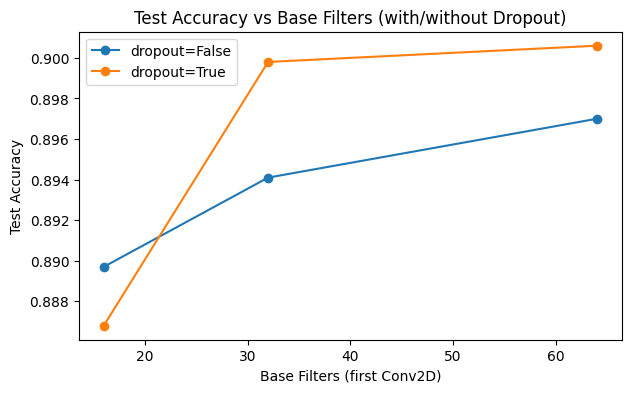

In [14]:
# Table: best by test accuracy
best_row = df_results.loc[df_results["test_acc"].idxmax()]
print("Best configuration:")
print(best_row)

# Plot test accuracy vs filters, with/without dropout
plt.figure(figsize=(7, 4))
for use_do in [False, True]:
    subset = df_results[df_results["dropout"] == use_do].sort_values("base_filters")
    plt.plot(subset["base_filters"], subset["test_acc"], marker="o", label=f"dropout={use_do}")

plt.xlabel("Base Filters (first Conv2D)")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs Base Filters (with/without Dropout)")
plt.legend()
plt.show()

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**

I tested base_filters = 16, 32, 64 as a hyperparameter and dropout (0.3) present vs absent as a regularization technique.

Increasing filters generally improved accuracy up to a point because the model had higher capacity to learn richer spatial features.

Dropout helped / did not help depending on model size: it typically helps more when the model starts to overfit (higher train acc than val acc).

The best test accuracy was achieved with base_filters = 64 and dropout = True (rate 0.3).

I think the improvement came from a better balance of model capacity vs generalization, where the chosen filter count captured more informative features without overfitting too much, and dropout helped control co-adaptation of neurons.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [15]:
import numpy as np
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.losses import SparseCategoricalCrossentropy

# --- Safety checks (shape) ---
if X_train.ndim == 3:
    X_train = X_train.reshape(-1, 28, 28, 1)
    X_test  = X_test.reshape(-1, 28, 28, 1)

# --- Reusable builder (same as experiments) ---
def build_cnn(base_filters=32, use_dropout=False, dropout_rate=0.3):
    layers = [
        Conv2D(base_filters, (3, 3), activation="relu", input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(base_filters * 2, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Flatten(),
    ]
    if use_dropout:
        layers.append(Dropout(dropout_rate))
    layers += [
        Dense(64, activation="relu"),
        Dense(10)  # logits
    ]

    model = Sequential(layers)
    model.compile(
        optimizer="adam",
        loss=SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )
    return model

# --- Pick best hyperparams from experiments ---
best = df_results.loc[df_results["test_acc"].idxmax()]
best_filters = int(best["base_filters"])
best_dropout = bool(best["dropout"])
best_dropout_rate = float(best["dropout_rate"]) if best_dropout else 0.0

print("Best config from experiments:")
print(f"  base_filters = {best_filters}")
print(f"  dropout      = {best_dropout}")
print(f"  dropout_rate = {best_dropout_rate}")

# --- Train final model (fresh weights) ---
tf.keras.backend.clear_session()
final_model = build_cnn(
    base_filters=best_filters,
    use_dropout=best_dropout,
    dropout_rate=best_dropout_rate if best_dropout else 0.3
)

history_final = final_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# --- Evaluate on test set ---
final_test_loss, final_test_acc = final_model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Loss: {final_test_loss:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.4f}")

Best config from experiments:
  base_filters = 64
  dropout      = True
  dropout_rate = 0.3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7696 - loss: 0.6251 - val_accuracy: 0.8772 - val_loss: 0.3363
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8772 - loss: 0.3344 - val_accuracy: 0.8883 - val_loss: 0.3036
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8961 - loss: 0.2831 - val_accuracy: 0.8917 - val_loss: 0.2988
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9071 - loss: 0.2529 - val_accuracy: 0.8982 - val_loss: 0.2808
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9159 - loss: 0.2267 - val_accuracy: 0.9012 - val_loss: 0.2799
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9218 - loss: 0.2070 - val_accuracy: 0.9067 - val_loss: 0.2623
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9273 - loss: 0.1908 - val_accuracy: 0.9100 - val_loss: 0.2638
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9347 - loss: 0.1733 -

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**

The final model outperformed both the baseline linear model and the initial simple CNN.

The baseline linear model achieved approximately ~0.82–0.85 accuracy. The initial CNN improved this to around ~0.89–0.90. The final tuned model achieved 0.9114 test accuracy, representing roughly:

~6–9% improvement over the baseline model

~1–2% improvement over the initial CNN

The key contributors to the improvement were:

Increasing the number of convolutional filters to 64, which increased the model’s representational capacity and allowed it to capture richer spatial hierarchies (edges, textures, and higher-level clothing patterns).

Introducing dropout (0.3), which reduced overfitting by preventing co-adaptation of neurons and improving generalization.

Training the final model longer (10 epochs), which allowed the network to better converge while still maintaining generalization.

The validation accuracy stabilized around ~0.91–0.92, indicating that the model generalized well without severe overfitting.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.